Midline successfully created after 0 attempts


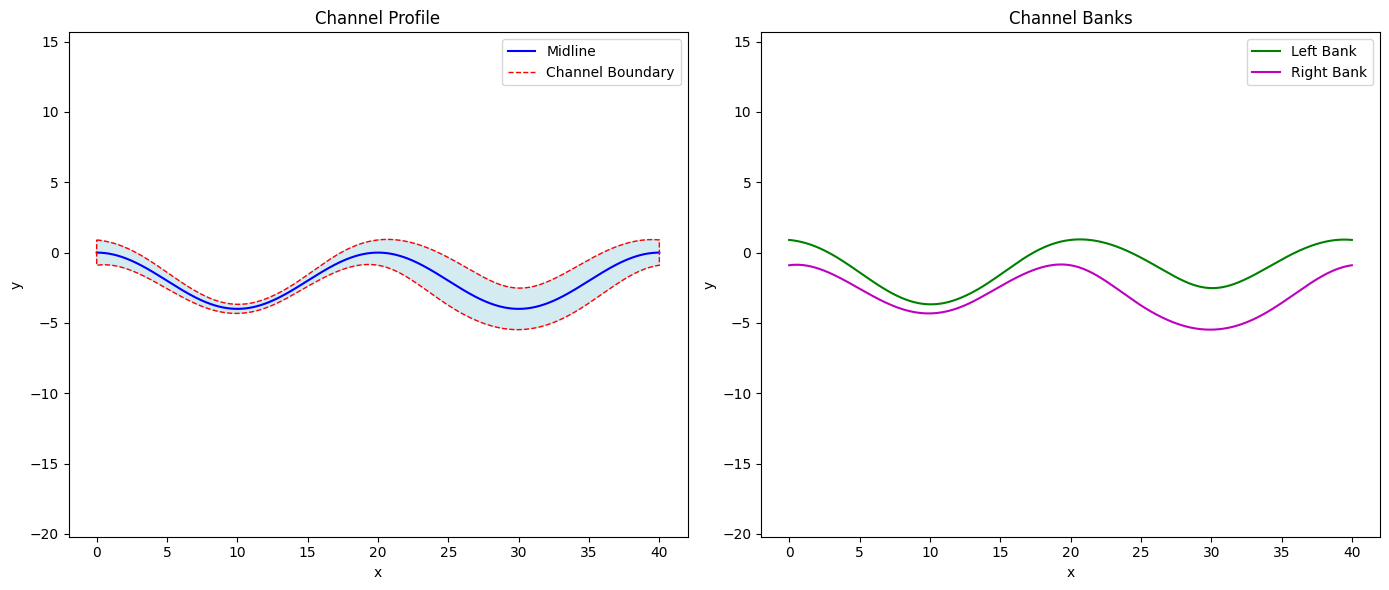

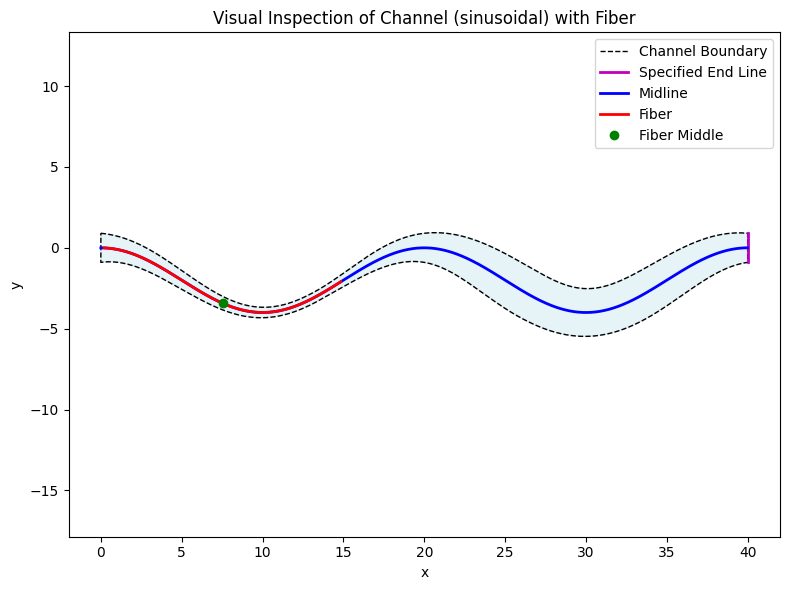

In [ ]:
import os
import bo_sheet.channel_preprocess_utility as cu
import numpy as np
import numpy.typing as npt

# Applicable to all channel types =============================================================================

'simple_straight'
'arc'
'straight'
's_shaped'
'sinusoidal'
'arbitrary'

# For the same channel, vary the friction coefficient by n_trials
channel_type = cu.ChannelType.simple_straight.value

# Shift 2mm to the right of start boundary, 20mm insertion space, 40mm crawl distance, 20mm extraction space
# 2mm is to avoid touching the start boundary which can act as a catapault
# 20mm and 40mm based on the longest optimization range robot length
init_wall_to_closest_tip_margin = 2.0
insertion_margin = 20.0
curved_section = 40.0
ending_margin = 22.0
L_total = init_wall_to_closest_tip_margin + insertion_margin + curved_section + ending_margin

L_total = init_wall_to_closest_tip_margin + insertion_margin + curved_section + ending_margin
L_window = 2.0 * 10.0 + init_wall_to_closest_tip_margin

# Subtract the ending 2mm margin and account for middle node of the longest robot
end_line_percent = (L_total - 2 - 10) / L_total

# Arbitrary is always non-constant width
constant_width = False

# If constant_width is True
width = 1.8

# If constant_width is False
num_width_ctrl = 5 # Must be >= 2
min_width = 0.6
max_width = 3.0
max_rate_width = 1.0

origin_offset = 0.0
N_points = 400

# Applicable to arc, s_shaped, sinusoidal, arbitrary settings ================================================

min_curvature = 0.002
max_curvature = 0.4
max_rate_curvature = 0.01

# For s_shaped and sinusoidal
amplitude = 2.0

# For sinusoidal
frequency = 2.0

# For arc
radius = curved_section / (220.0 * np.pi / 180.0)

# For arbitrary
n_bending = 4

channel_directory = os.path.join(os.path.expanduser('~'),
                                      'Documents', 'GitHub', 'Bayesian_Optimization_for_Sheet_Robots',
                                      'tasks', '3_optim_shape', 'channel_params')

# End of channel settings ====================================================================================

x_midline, y_midline, channel_polygon, left_bank, right_bank = cu.generate_closed_channel(
    L_total, n_bending, num_width_ctrl, max_curvature, min_curvature, max_width,
    min_width, max_rate_curvature, max_rate_width,
    channel_type, width, amplitude, frequency, radius, constant_width,
    origin_offset, N_points, backward=False, init_wall_to_closest_tip_margin=init_wall_to_closest_tip_margin,
    insertion_margin=insertion_margin, curved_section=curved_section, ending_margin=ending_margin
)

cu.plot_channel_all_info(x_midline, y_midline, channel_polygon, left_bank, right_bank)

# For shapely to read the channel information
with open(os.path.join(channel_directory, channel_type, "polygon.wkt"), "w") as file:
    file.write(channel_polygon.wkt)
file.close()

channel_info = {
    "x_midline": x_midline,
    "y_midline": y_midline,
    "left_bank": left_bank,
    "right_bank": right_bank,
    "total_length": L_total
}

# For numpy to store the quantitative channel information
np.savez(os.path.join(channel_directory, channel_type, 'channel_info'), **channel_info)

left_bank_numpy: npt.NDArray[np.float64] = np.column_stack(left_bank)  # Shape: (N, 2)
right_bank_numpy: npt.NDArray[np.float64] = np.column_stack(right_bank)  # Shape: (N, 2)

z_axis = np.full((left_bank_numpy.shape[0], 1), 0.0)

txt_left_bank = np.hstack((left_bank_numpy, z_axis))
txt_right_bank = np.hstack((right_bank_numpy, z_axis))

# For 3D printing channel construction
np.savetxt(os.path.join(channel_directory, channel_type, 'boundary_pos.txt'), txt_left_bank, fmt='%.2f', delimiter=',')

with open(os.path.join(channel_directory, channel_type, 'boundary_pos.txt'), 'a') as file:
    np.savetxt(file, txt_right_bank, fmt='%.2f', delimiter=',')
file.close()

# Generate fiber in the channel
# Convert midline to the format expected by generate_fiber_in_segment
seg_midline = np.column_stack((x_midline, y_midline))  # Shape: (M, 2)

# Visualize
L_fiber = 16.0

# (init_wall_to_closest_tip_margin + (longest_robot - L_fiber) / 2) / L_total
offset_factor = (init_wall_to_closest_tip_margin + (insertion_margin - L_fiber) / 2) / L_total
N_fiber = 50

fiber = cu.generate_fiber_in_segment(seg_midline, L_fiber=L_fiber, offset_factor=offset_factor, N_fiber=N_fiber)

# Plot the channel with the fiber
cu.plot_channel_and_fiber(channel_polygon, seg_midline, fiber, title=f"Visual Inspection of Channel ({channel_type}) with Fiber", end_line_percent=end_line_percent)